In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz
from utils.cub_config import Config

d:\Programas\Anaconda\envs\ia_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda:0


In [3]:
model_path = Config.MODEL
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 200)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
preprocess = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [5]:
test_images = [
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg"
]


Imagem: ../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg
Classe Predita: 26 (Prob: 0.1876)


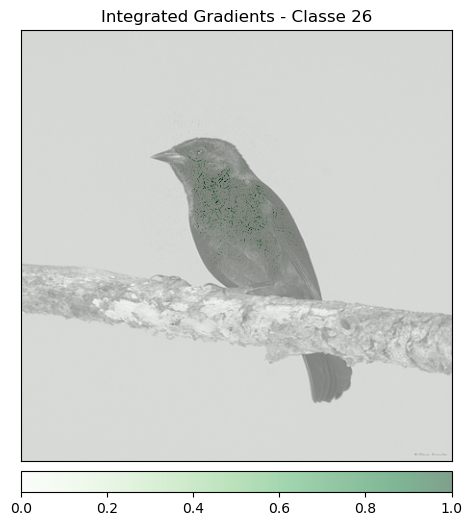

Explicação salva em: ../../out\ig_Shiny_Cowbird_0015_796858.jpg


In [6]:
ig = IntegratedGradients(model)

for img_path in test_images:

    image = Image.open(img_path).convert('RGB')
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    input_tensor.requires_grad_()

    output = model(input_tensor)
    pred_prob = F.softmax(output, dim=1)
    pred_class_idx = torch.argmax(pred_prob, dim=1).item()
    pred_class_prob = pred_prob[0, pred_class_idx].item()

    print(f"\nImagem: {img_path}")
    print(f"Classe Predita: {pred_class_idx} (Prob: {pred_class_prob:.4f})")

    baseline = torch.zeros_like(input_tensor).to(device)

    attributions_ig = ig.attribute(input_tensor,
                                   baselines=baseline,
                                   target=pred_class_idx,
                                   n_steps=50,
                                   internal_batch_size=10,
                                   return_convergence_delta=False)
    

    attr_np = attributions_ig.squeeze().cpu().detach().numpy()
    attr_np = np.transpose(attr_np, (1, 2, 0))

    img_np = np.array(image.resize((448, 448))) / 255.0


    fig, _ = viz.visualize_image_attr(
        attr_np,
        img_np,
        method="blended_heat_map",
        sign="positive",  
        show_colorbar=True,
        title=f"Integrated Gradients - Classe {pred_class_idx}",
        use_pyplot=True 
    )
    
    # Salvar a figura
    out_filename = f"ig_{os.path.basename(img_path)}"
    save_path = os.path.join(Config.OUTPUT_DIR, out_filename)
    fig.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"Explicação salva em: {save_path}")
    
    plt.close()


In [7]:
from cub_eval import deletion_test

In [8]:
print(attr_np.shape)
sal_map = np.mean(np.abs(attr_np), axis=2)
print(sal_map.shape)

(448, 448, 3)
(448, 448)


In [10]:
image_path = "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg"
img = Image.open(image_path).convert('RGB')
input_tensor = preprocess(img).unsqueeze(0).to(device)

preds = model(input_tensor)
pred_class = torch.argmax(preds, dim=1).item()
print(f"Predicted class: {pred_class}")



sal_map = np.mean(np.abs(attr_np), axis=2)
confidences, predictions, broke = deletion_test(model, input_tensor, sal_map, pred_class, max_steps=100)

print(f"Broke at step: {broke}")

Predicted class: 26
Broke at step: 3


Text(0.5, 1.0, 'Deletion Test')

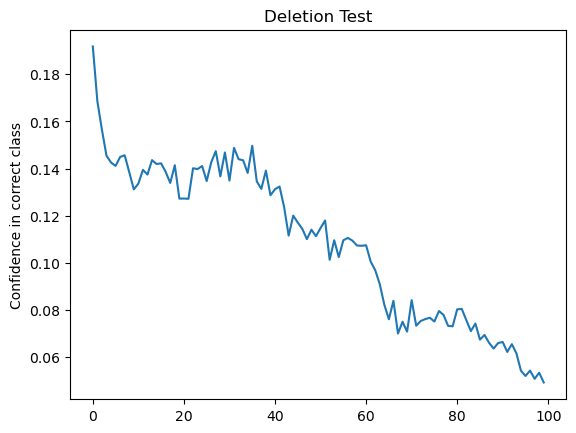

In [11]:
## plot confidences

plt.plot(confidences)
plt.ylabel('Confidence in correct class')
plt.title('Deletion Test')

Text(0.5, 1.0, 'Deletion Test')

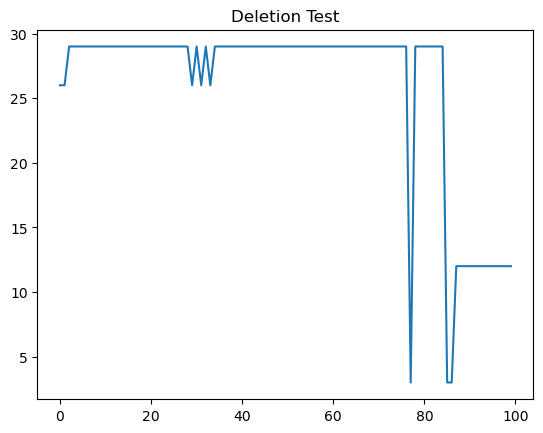

In [12]:
plt.plot(predictions)
plt.title('Deletion Test')

## ROBUSTNESS

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from cub_eval import robustness_test
robustness_score = robustness_test(model, 'IG', input_tensor, ig.attribute)
print(f"Robustness score: {robustness_score}")

Robustness score: 0.10136049181113763


## SPARSITY AND SPATIAL COHERENCE

In [17]:
from cub_eval import calculate_gini_index, calculate_spatial_coherence


gini_index = calculate_gini_index(sal_map)
print(f"Gini Index: {gini_index}")

coherence = calculate_spatial_coherence(sal_map)
print(f"Spatial Coherence: {coherence}")

Gini Index: 0.8781312085818663
Spatial Coherence: 0.07860216197126121


## INTRA CLASS CONSISTENCY

In [18]:
test_images_26 = [
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0085_796839.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0035_796837.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0034_796849.jpg",
]


Imagem: ../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg
Classe Predita: 26 (Prob: 0.1876)


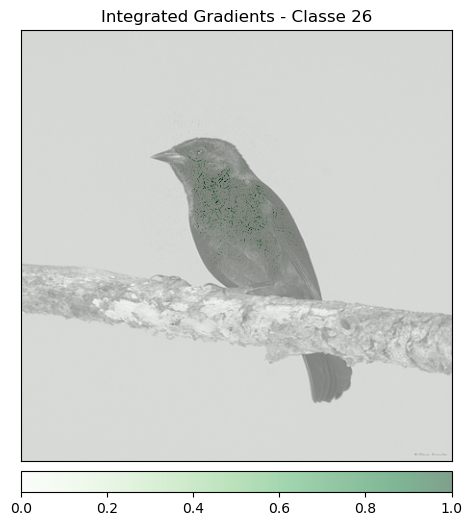

Explicação salva em: ../../out\ig_Shiny_Cowbird_0015_796858.jpg

Imagem: ../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0085_796839.jpg
Classe Predita: 26 (Prob: 0.2294)


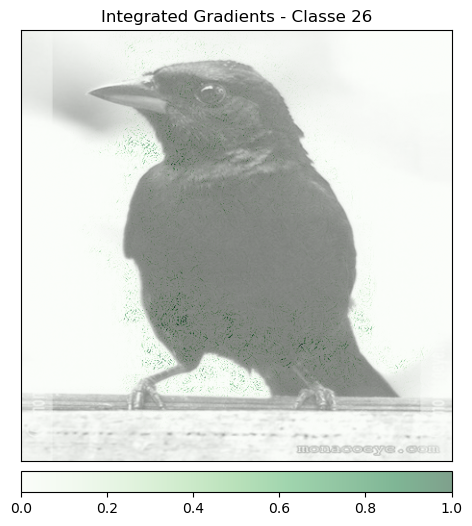

Explicação salva em: ../../out\ig_Shiny_Cowbird_0085_796839.jpg

Imagem: ../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0035_796837.jpg
Classe Predita: 25 (Prob: 0.3495)


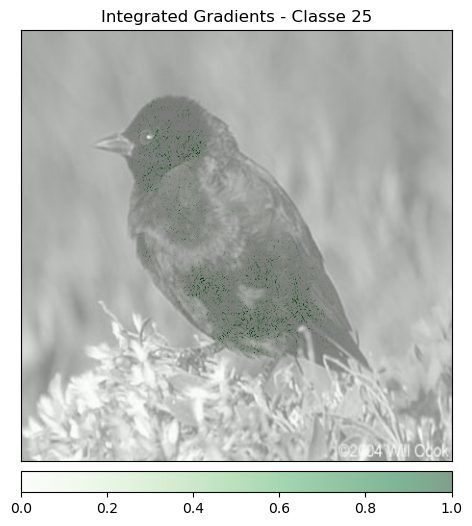

Explicação salva em: ../../out\ig_Shiny_Cowbird_0035_796837.jpg

Imagem: ../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0034_796849.jpg
Classe Predita: 26 (Prob: 0.3467)


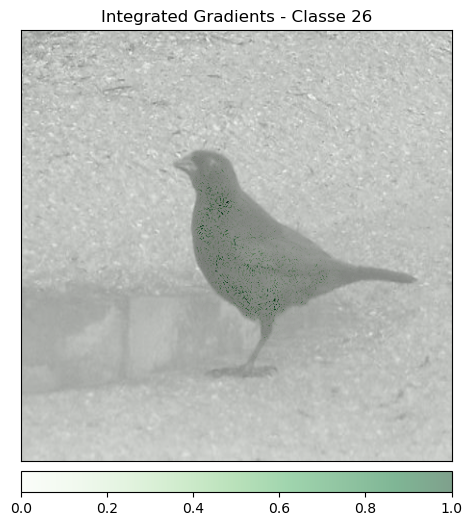

Explicação salva em: ../../out\ig_Shiny_Cowbird_0034_796849.jpg


In [19]:
ig = IntegratedGradients(model)
heatmaps = []
for img_path in test_images_26:

    image = Image.open(img_path).convert('RGB')
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    input_tensor.requires_grad_()

    output = model(input_tensor)
    pred_prob = F.softmax(output, dim=1)
    pred_class_idx = torch.argmax(pred_prob, dim=1).item()
    pred_class_prob = pred_prob[0, pred_class_idx].item()

    print(f"\nImagem: {img_path}")
    print(f"Classe Predita: {pred_class_idx} (Prob: {pred_class_prob:.4f})")

    baseline = torch.zeros_like(input_tensor).to(device)

    attributions_ig = ig.attribute(input_tensor,
                                   baselines=baseline,
                                   target=pred_class_idx,
                                   n_steps=50,
                                   internal_batch_size=10,
                                   return_convergence_delta=False)
    

    attr_np = attributions_ig.squeeze().cpu().detach().numpy()
    attr_np = np.transpose(attr_np, (1, 2, 0))

    img_np = np.array(image.resize((448, 448))) / 255.0


    fig, _ = viz.visualize_image_attr(
        attr_np,
        img_np,
        method="blended_heat_map",
        sign="positive",  
        show_colorbar=True,
        title=f"Integrated Gradients - Classe {pred_class_idx}",
        use_pyplot=True 
    )
    
    # Salvar a figura
    out_filename = f"ig_{os.path.basename(img_path)}"
    save_path = os.path.join(Config.OUTPUT_DIR, out_filename)
    fig.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"Explicação salva em: {save_path}")
    
    plt.close()

    heatmap = np.mean(np.abs(attr_np), axis=2)
    heatmaps.append(heatmap)


In [20]:
from cub_eval import intraclass_consistency

consistency = intraclass_consistency(heatmaps)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.19902720446739708
